### Question 2

Build a Naive Bayes classifier and Logistic Regression classifier for binary classification
of the comments as cyberbullying or not cyberbullying. To complete this question you have to do the
following tasks:

1. Data Preparation (use scikit-learn [1] or NLTK [2])

2. Naive Bayes Classification (use scikit-learn [1] or NLTK [2])

3. Logistic Regression Classification (use scikit-learn [1])

4. Write one page short report 

#### 2.1 Solution - Data preparation



##### Basic data exploration

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
import os
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/helenavalk/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/helenavalk/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [17]:
df = pd.read_csv("CyberBullying Comments Dataset.csv")

#looking at the very basics first
print(df.shape)
print(df.columns.tolist()) #we only have 2 columns, the actual tweet and then its classification
print(df['CB_Label'].value_counts()) #there are 5550 records of both types (cyberbullying and not) so the data is extremely balanced
print("\nData types:\n", df.dtypes)

df.head(10)

(11100, 2)
['Text', 'CB_Label']
0    5550
1    5550
Name: CB_Label, dtype: int64

Data types:
 Text        object
CB_Label     int64
dtype: object


,Text,CB_Label
0,damn there is someones nana up here at beach w...,0
1,no kidding! dick clark was a corpse mechanical...,0
2,i read an article on jobros and thought damn w...,0
3,I got one fucking day of sprinkles and now it'...,0
4,I was already listening to Elliott smith and ...,0
5,I told Derek to go fuck himself Devyn told us...,0
6,I'm watching the new Smosh video and laughing ...,0
7,My mom didn't like Catholicism because the ide...,0
8,ya i know! lol AND big thunder mountain broke ...,0
9,"lucky bitch.....""",0


In [18]:
#checking for any missing values

print("\nMissing values per column:")
print(df.isnull().sum())

#there are no missing values, every tweet has a classification


Missing values per column:
Text        0
CB_Label    0
dtype: int64


In [19]:
#checking for any duplicates - there are none

print("\nNumber of duplicate rows:", df.duplicated().sum())


Number of duplicate rows: 0


In [20]:
#looking at the length of tweets and the words in the tweets for each class to understand any differences

#creating two new columns (can delete later)
df["text_length"] = df["Text"].str.len()
df["word_count"] = df["Text"].str.split().str.len()

print("\nText length statistics:")
print(df.groupby("CB_Label")["text_length"].describe().round(1))

print("\nWord count statistics:")
print(df.groupby("CB_Label")["word_count"].describe().round(1))

#cyberbullying tweets have a much higher average character length and a higher average word count


Text length statistics:
           count   mean    std  min   25%   50%    75%     max
CB_Label                                                      
0         5550.0   73.9   48.9  2.0  40.0  70.0  108.0  1738.0
1         5550.0  104.4  128.1  1.0  40.0  75.0  122.0  4016.0

Word count statistics:
           count  mean   std  min  25%   50%   75%    max
CB_Label                                                 
0         5550.0  14.1   9.6  1.0  7.0  13.0  20.0  343.0
1         5550.0  18.9  22.2  1.0  7.0  14.0  23.0  703.0


##### Preprocessing of the text data

In [23]:
from nltk.stem import SnowballStemmer

#initializing stopwords and the stemmer
stop_words = set(stopwords.words('english'))
sb = SnowballStemmer('english')

#defining a function for preprocessing (as shown in the sample exercise)
def data_preprocess(text):
    
    #removing punctuation and special characters
    text = re.sub(r'[^a-zA-Z\s]', '', str(text))
    
    #converting all text to lowercase
    text = text.lower()
    
    #tokenizing by word
    tokens = word_tokenize(text)
    
    #removing stopwords and stemming the words
    new_tokens = []
    for w in tokens:
        if w not in stop_words:
            stem_word = sb.stem(w)
            new_tokens.append(stem_word)
    
    return new_tokens

#applying the function to our dataset
df['tokens'] = df['Text'].apply(data_preprocess)

#reviewing the result
df[['Text', 'tokens', 'CB_Label']].head(10)

#SnowballStemmer reduces words to a stem, which is not always a real English word - so that's why some of the oututs look weird

,Text,tokens,CB_Label
0,damn there is someones nana up here at beach w...,"[damn, someon, nana, beach, one, dont, think, ...",0
1,no kidding! dick clark was a corpse mechanical...,"[kid, dick, clark, corps, mechan, oper, advert...",0
2,i read an article on jobros and thought damn w...,"[read, articl, jobro, thought, damn, cash, job...",0
3,I got one fucking day of sprinkles and now it'...,"[got, one, fuck, day, sprinkl, back, sunshin, ...",0
4,I was already listening to Elliott smith and ...,"[alreadi, listen, elliott, smith, fuck, hate, ...",0
5,I told Derek to go fuck himself Devyn told us...,"[told, derek, go, fuck, devyn, told, us, calm]",0
6,I'm watching the new Smosh video and laughing ...,"[im, watch, new, smosh, video, laugh, ass]",0
7,My mom didn't like Catholicism because the ide...,"[mom, didnt, like, catholic, idea, sinner, bir...",0
8,ya i know! lol AND big thunder mountain broke ...,"[ya, know, lol, big, thunder, mountain, broke,...",0
9,"lucky bitch.....""","[lucki, bitch]",0


##### Test and train split

In [27]:
from sklearn.model_selection import train_test_split

#joining tokens back into a string because TF-IDF needs plain text not list
df['clean_text'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

#defining features X and Y
X = df['clean_text']   #preprocessed tweet text
y = df['CB_Label']     #0 = not cyberbullying, 1 = cyberbullying

#splitting into train and test sets 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("training samples:", len(X_train))
print("test samples:", len(X_test))


training samples: 8880
test samples: 2220


##### Vectorization with TF-IDF

Bag of Words just counts how many times a word appears, so common words would dominate. TF-IDF penalises words that appear in many tweets, so words that are distinctive to cyberbullying tweets (such as slurs, targeting language) get higher weight.

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

#initializing tfidf vectorizer
tfidf = TfidfVectorizer()

#using fit_transform on training set (which learns the vocabulary and transforms text)
X_train_tfidf = tfidf.fit_transform(X_train)

#using only transform on test set (which uses the vocabulary learned from training set)
X_test_tfidf = tfidf.transform(X_test)

print("\nshape of training matrix:", X_train_tfidf.shape)
print("shape of test matrix:", X_test_tfidf.shape)
print("shape of y_train:", y_train.shape)
print("shape of y_test:", y_test.shape)



shape of training matrix: (8880, 13799)
shape of test matrix: (2220, 13799)
shape of y_train: (8880,)
shape of y_test: (2220,)


##### Naive Bayes Classification with scikit-learn

In [31]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#initializing the Naive Bayes model
nb_model = MultinomialNB()

#training the model on the training data
nb_model.fit(X_train_tfidf, y_train)

#using the trained Naive Bayes model to predict the class labels for the test data
y_predicted_labels = nb_model.predict(X_test_tfidf)

#evaluating the model
nb_accuracy = accuracy_score(y_test, y_predicted_labels)
nb_precision = precision_score(y_test, y_predicted_labels)
nb_recall = recall_score(y_test, y_predicted_labels)
nb_f1 = f1_score(y_test, y_predicted_labels)

#printing the results
print("Naive Bayes results:")
print("accuracy:", round(nb_accuracy, 4))
print("precision:", round(nb_precision, 4))
print("recall:", round(nb_recall, 4))
print("f1-score:", round(nb_f1, 4))

Naive Bayes results:
accuracy: 0.7086
precision: 0.7167
recall: 0.674
f1-score: 0.6947


##### Looking at what the Naive Bayes model actually learned

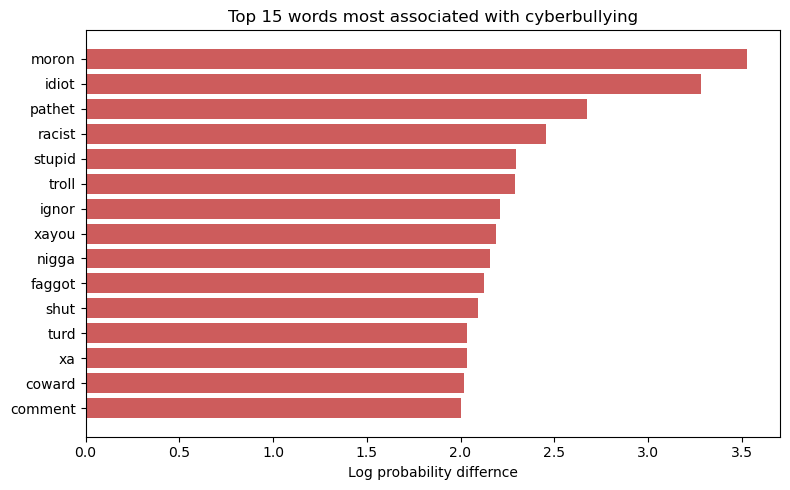

In [36]:
#looking at the words most associated with each class
feature_names = tfidf.get_feature_names_out()

#getting the log probabilities learned by the Naive Bayes model for cyberbullying
log_probs = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]

#getting the top 15 words most associated with cyberbullying
top_indices = log_probs.argsort()[-15:]
top_words = [feature_names[i] for i in top_indices]
top_scores = [log_probs[i] for i in top_indices]

plt.figure(figsize=(8, 5))
plt.barh(top_words, top_scores, color='indianred')
plt.xlabel('Log probability differnce')
plt.title('Top 15 words most associated with cyberbullying')
plt.tight_layout()
plt.show()

##### Logistic Regression Classification with scikit-learn 

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

#initializing the Logistic Regression model
lr_model = LogisticRegression(max_iter=1000) #allowing the model up to 1000 iterations to find the best solution

#training the model on the TF-IDF training data
lr_model.fit(X_train_tfidf, y_train)

#making predictions on the TF-IDF test data
y_predicted_labels_lr = lr_model.predict(X_test_tfidf)

#calculating evaluation metrics
lr_accuracy = accuracy_score(y_test, y_predicted_labels_lr)
lr_precision = precision_score(y_test, y_predicted_labels_lr)
lr_recall = recall_score(y_test, y_predicted_labels_lr)
lr_f1 = f1_score(y_test, y_predicted_labels_lr)

#printing the results
print("Logistic Regression results:")
print("accuracy:", round(lr_accuracy, 4))
print("precision:", round(lr_precision, 4))
print("recall:", round(lr_recall, 4))
print("f1-score:", round(lr_f1, 4))


Logistic Regression results:
accuracy: 0.7338
precision: 0.7468
recall: 0.6941
f1-score: 0.7195


##### Confusion matrices for both models

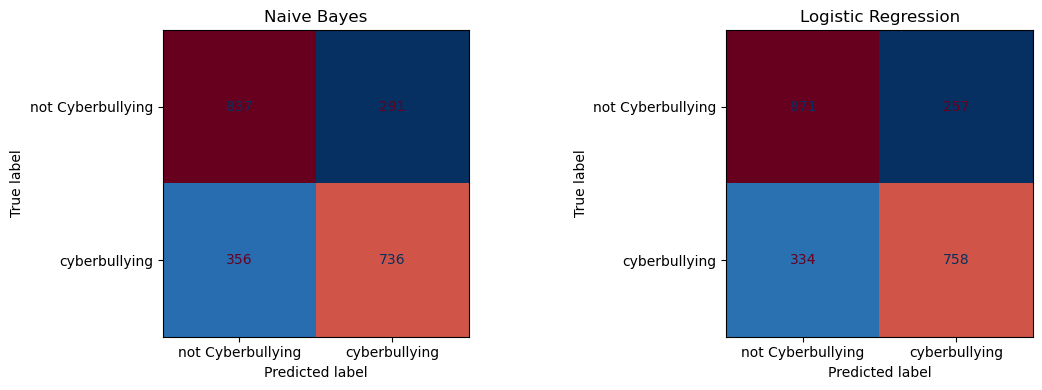

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

#creating the Naive Bayes confusion matrix
cm_nb = confusion_matrix(y_test, y_predicted_labels)
ConfusionMatrixDisplay(cm_nb, display_labels=['not Cyberbullying', 'cyberbullying']).plot(ax=axes[0], colorbar=False, cmap='RdBu_r')
axes[0].set_title('Naive Bayes')

#creating the Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_predicted_labels_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['not Cyberbullying', 'cyberbullying']).plot(ax=axes[1], colorbar=False, cmap='RdBu_r')
axes[1].set_title('Logistic Regression')

plt.tight_layout()
plt.show()

#top left = correctly identified non-bullying
#bottom right = correctly identified bullying
#top right = false alarms
#bottom left = missed bullying cases